<a href="https://colab.research.google.com/github/ngoan22mse23088/ArtificialIntelligence/blob/master/Lung_Cance_Detection_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About The Project

This project focuses on lung cancer detection using CT scan images from the **IQ-OTH/NCCD Lung Cancer Dataset**, collected by *The Iraq Oncology Teaching Hospital / National Center for Cancer Diseases*. The dataset includes three classes: **Normal**, **Benign**, and **Malignant**.

A **ResNet-18** model pretrained on **ImageNet** was used through **transfer learning**. The final fully connected layer was replaced to match the three output classes, and **all layers were fine-tuned** to adapt the model to medical imaging data. The model was trained using `CrossEntropyLoss`, the `AdamW` optimizer, and a `ReduceLROnPlateau` learning rate scheduler.

Performance was evaluated using `test loss`, `accuracy`, `classification report`, and `a confusion matrix`. The fine-tuned ResNet-18 achieved strong classification performance, demonstrating the effectiveness of transfer learning for automated lung cancer detection.

Re-Check Images


In [7]:
import kagglehub
from pathlib import Path
from collections import defaultdict
import json
from PIL import Image
import numpy as np

# Download dataset
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
print("Path to dataset files:", path)

# ── Tự động tìm ảnh trong path vừa download ──
root = Path(path)
ALLOWED_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".tif"}
EXPECTED_MODES = {"RGB", "L"}

image_files = [f for f in root.rglob("*")
               if f.is_file() and f.suffix.lower() in ALLOWED_EXTS]

print(f"\n📁 Dataset: {root}")
print(f"🖼️  Tổng số ảnh: {len(image_files)}")

if len(image_files) == 0:
    all_files = list(root.rglob("*.*"))
    exts = set(f.suffix.lower() for f in all_files if f.is_file())
    print(f"⚠️  Không tìm thấy ảnh! Extensions thực tế: {exts}")
    for f in all_files[:10]:
        print(f"  {f.relative_to(root)}")
else:
    errors        = []
    size_counter  = defaultdict(int)
    mode_counter  = defaultdict(int)
    class_counter = defaultdict(int)
    ext_counter   = defaultdict(int)

    for i, p in enumerate(image_files, 1):
        if i % 300 == 0:
            print(f"  ... {i}/{len(image_files)}")
        issues = []
        class_counter[p.parent.name] += 1
        ext_counter[p.suffix.lower()] += 1

        if p.stat().st_size < 1024:
            issues.append(f"File quá nhỏ ({p.stat().st_size} bytes)")

        try:
            with Image.open(p) as img:
                w, h, mode = img.width, img.height, img.mode
                size_counter[f"{w}x{h}"] += 1
                mode_counter[mode] += 1
                if mode not in EXPECTED_MODES:
                    issues.append(f"Mode không hợp lệ: {mode}")
                if np.array(img).std() < 1.0:
                    issues.append("Ảnh một màu (std≈0)")
        except Exception as e:
            issues.append(f"Không đọc được: {e}")

        if issues:
            errors.append({"file": str(p.relative_to(root)), "issues": issues})

    total = len(image_files)
    n_ok  = total - len(errors)

    print(f"\n{'═'*55}")
    print(f"  Tổng ảnh    : {total}")
    print(f"  ✅ Đạt chuẩn : {n_ok}  ({n_ok/total*100:.1f}%)")
    print(f"  ❌ Có vấn đề : {len(errors)}  ({len(errors)/total*100:.1f}%)")

    print(f"\n  📂 PHÂN BỐ THEO CLASS:")
    max_c = max(class_counter.values())
    for cls, cnt in sorted(class_counter.items()):
        bar = "█" * int(cnt / max_c * 25)
        print(f"    {cls:<30} {cnt:>4}  {bar}")

    print(f"\n  📐 KÍCH THƯỚC PHỔ BIẾN:")
    for size, cnt in sorted(size_counter.items(), key=lambda x: -x[1])[:8]:
        print(f"    {size:<15} {cnt:>4} ảnh")

    print(f"\n  🎨 MODE MÀU:")
    for mode, cnt in sorted(mode_counter.items(), key=lambda x: -x[1]):
        mark = "✅" if mode in EXPECTED_MODES else "❌"
        print(f"    {mode:<10} {cnt:>4} ảnh  {mark}")

    print(f"\n  📄 ĐỊNH DẠNG FILE:")
    for ext, cnt in sorted(ext_counter.items(), key=lambda x: -x[1]):
        print(f"    {ext:<10} {cnt:>4} ảnh")

    if errors:
        print(f"\n  ❌ MẪU LỖI (tối đa 20):")
        for e in errors[:20]:
            print(f"  [{e['file']}]")
            for iss in e["issues"]:
                print(f"    → {iss}")
        out = Path("/kaggle/working/error_images.json")
        out.write_text(json.dumps(errors, ensure_ascii=False, indent=2))
        print(f"\n  📋 Đã lưu lỗi → {out}")
    else:
        print(f"\n  🎉 Tất cả ảnh đều đạt chuẩn!")
    print(f"{'═'*55}")

Using Colab cache for faster access to the 'iqothnccd-lung-cancer-dataset' dataset.
Path to dataset files: /kaggle/input/iqothnccd-lung-cancer-dataset

📁 Dataset: /kaggle/input/iqothnccd-lung-cancer-dataset
🖼️  Tổng số ảnh: 1294
  ... 300/1294
  ... 600/1294
  ... 900/1294
  ... 1200/1294

═══════════════════════════════════════════════════════
  Tổng ảnh    : 1294
  ✅ Đạt chuẩn : 1294  (100.0%)
  ❌ Có vấn đề : 0  (0.0%)

  📂 PHÂN BỐ THEO CLASS:
    Bengin cases                    120  █████
    Malignant cases                 561  █████████████████████████
    Normal cases                    416  ██████████████████
    Test cases                      197  ████████

  📐 KÍCH THƯỚC PHỔ BIẾN:
    512x512         1230 ảnh
    623x512           31 ảnh
    801x512           28 ảnh
    768x768            3 ảnh
    506x331            1 ảnh
    511x404            1 ảnh

  🎨 MODE MÀU:
    RGB        1294 ảnh  ✅

  📄 ĐỊNH DẠNG FILE:
    .jpg       1097 ảnh
    .png        197 ảnh

  🎉 Tất cả ảnh

# Imports
Importing all necessary libraries for this project

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from torchvision.models import resnet18, ResNet18_Weights

# Configs
Setting some important configurations and hyperparameters which is to be used in the project

In [ ]:
DATA_DIR = '/kaggle/input/the-iqothnccd-lung-cancer-dataset/The IQ-OTHNCCD lung cancer dataset'
OUT_DIR = 'model'

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-4
WEIGHT_DECAY = 1e-5
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

os.makedirs(OUT_DIR, exist_ok=True)
print(f'Using device: {DEVICE}')

Using device: cuda


# Seed
Setting seed so that the model produces same result on every run

In [ ]:
def setSeed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

setSeed(SEED)

# Class & Image Count

In [ ]:
import kagglehub
from pathlib import Path

# Download latest version
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
print("Path to dataset files:", path)

# Use the returned path instead of a hardcoded one
DATA_DIR = path  # ← this is the fix

def findImagePaths(data_dir, exts=('.png', '.jpg', '.jpeg')):
    data_dir = Path(data_dir)
    classes = []
    samples = []
    for cls_dir in sorted([d for d in data_dir.iterdir() if d.is_dir()]):
        cls_name = cls_dir.name
        classes.append(cls_name)
        for p in cls_dir.rglob('*'):
            if p.suffix.lower() in exts:
                samples.append((str(p), cls_name))
    return samples, classes

samples, classes = findImagePaths(DATA_DIR)
print(f'Classes: {classes}')
print(f'Total images: {len(samples)}')

Using Colab cache for faster access to the 'iqothnccd-lung-cancer-dataset' dataset.
Path to dataset files: /kaggle/input/iqothnccd-lung-cancer-dataset
Classes: ['Test cases', 'The IQ-OTHNCCD lung cancer dataset']
Total images: 1294


# Class Distribution

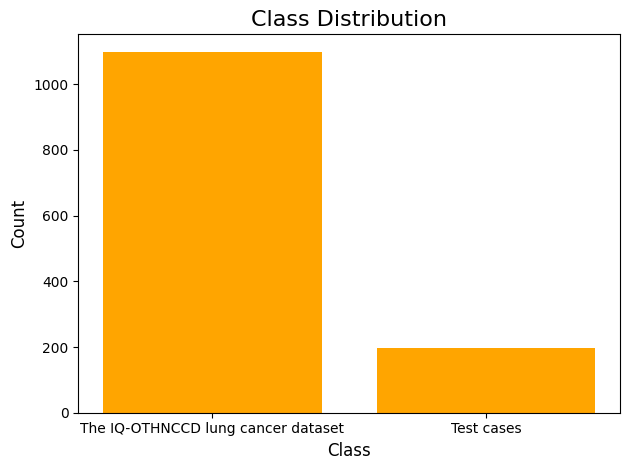

The IQ-OTHNCCD lung cancer dataset: 1097
Test cases: 197


In [ ]:
labels = [s[1] for s in samples]
counts = Counter(labels)

counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))

classes = list(counts.keys())
values = list(counts.values())

bars = plt.bar(classes, values, color='orange')

plt.title('Class Distribution', fontsize=16)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

for cls, count in counts.items():
    print(f'{cls}: {count}')

# Sample Dataset Images
Plotting 4 images per class

0 The IQ-OTHNCCD lung cancer dataset
1 Test cases


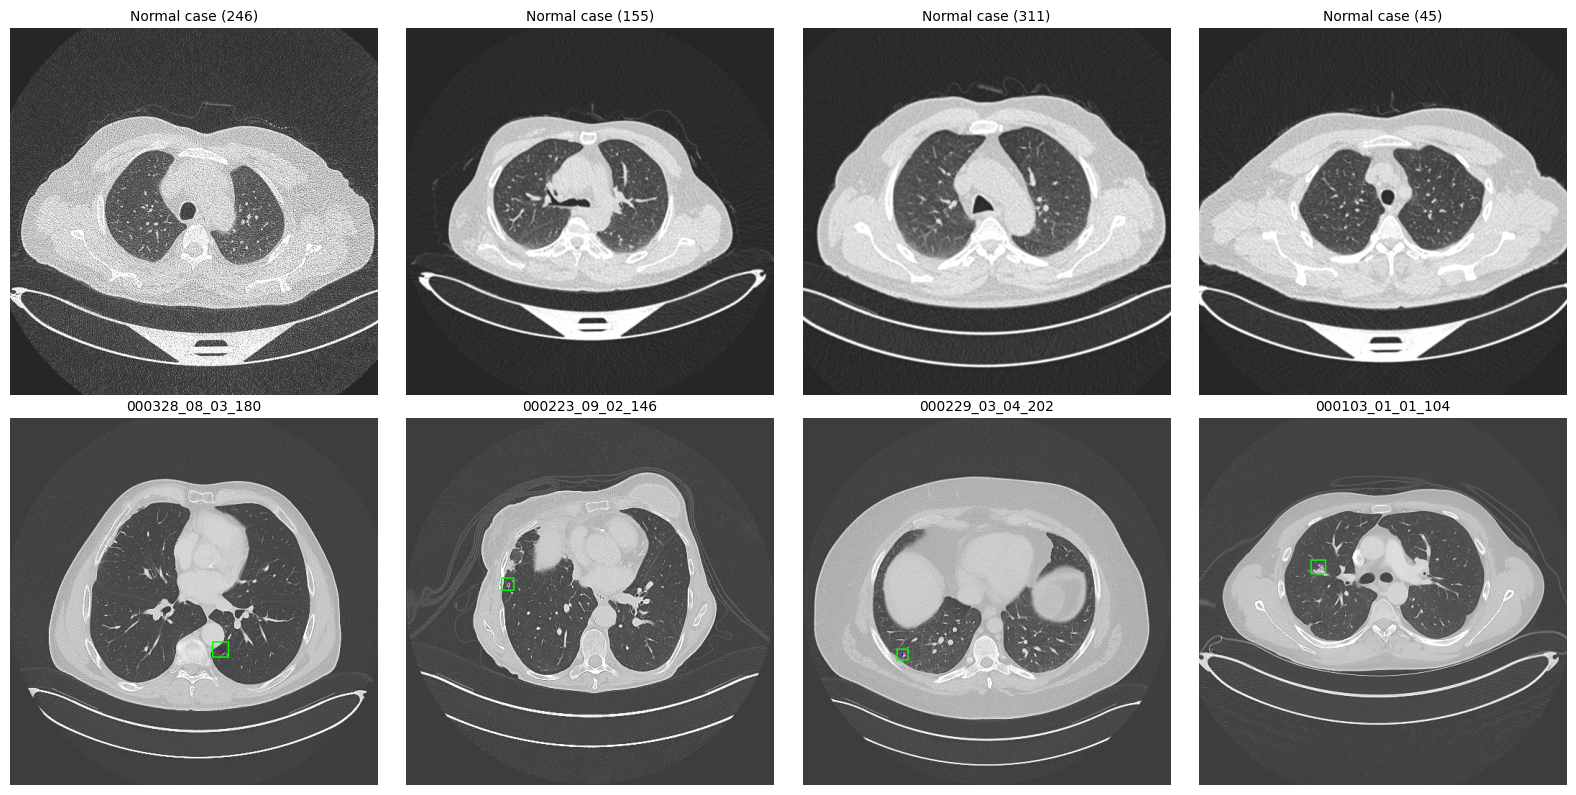

In [ ]:
n_per_class = 4
fig, axes = plt.subplots(len(classes), n_per_class, figsize=(n_per_class*4, len(classes)*4))

for i, cls in enumerate(classes):
    print(i, cls)
    cls_imgs = [s[0] for s in samples if s[1] == cls][:n_per_class]
    for j, path in enumerate(cls_imgs):
        img = Image.open(path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        label = os.path.splitext(os.path.basename(path))[0]
        axes[i, j].set_title(label, fontsize=10, pad=5)
        if j == 0:
            axes[i, j].set_ylabel(cls, rotation=0, labelpad=30, fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# Dataset Class Declaration

In [ ]:
class ScannedImageDataset(Dataset):
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[cls]
        return img, label

# Split Data

In [ ]:
class_to_idx = {c: i for i, c in enumerate(classes)}
paths = [s[0] for s in samples]
labels = [class_to_idx[s[1]] for s in samples]

trainval_idx, test_idx = train_test_split(
    np.arange(len(samples)), test_size=0.1, stratify=labels, random_state=SEED
)
train_idx, val_idx = train_test_split(
    trainval_idx, test_size=0.2, stratify=np.array(labels)[trainval_idx], random_state=SEED
)

train_samples = [samples[i] for i in train_idx]
val_samples = [samples[i] for i in val_idx]
test_samples = [samples[i] for i in test_idx]

print(f'Train: {len(train_samples)}, Val: {len(val_samples)}, Test: {len(test_samples)}')

Train: 931, Val: 233, Test: 130


# Transformation & Data Loaders

Here the `mean` and `std` values are taken as per `ImageNet`

In [ ]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

train_ds = ScannedImageDataset(train_samples, class_to_idx, transform=train_transform)
val_ds   = ScannedImageDataset(val_samples, class_to_idx, transform=test_transform)
test_ds  = ScannedImageDataset(test_samples, class_to_idx, transform=test_transform)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE)

# ResNet-18
For transfer learning and using that to classify lung cancer images

In [ ]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))

model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


In [ ]:
def trainOneEpoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct = 0, 0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Eval', leave=True):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset), \
    np.array(preds_all), np.array(labels_all)

# Training
Here the model is trained for just 5 epochs


Epoch 1/5


Eval: 100%|██████████| 8/8 [00:03<00:00,  2.32it/s]


Train Loss: 0.1288, Acc: 0.9398
Val   Loss: 0.0527, Acc: 0.9785
Model saved

Epoch 2/5


Eval: 100%|██████████| 8/8 [00:01<00:00,  4.22it/s]


Train Loss: 0.0062, Acc: 0.9989
Val   Loss: 0.0017, Acc: 1.0000
Model saved

Epoch 3/5


...

Train Loss: 0.0048, Acc: 0.9989
Val   Loss: 0.0022, Acc: 1.0000

Epoch 4/5


Eval: 100%|██████████| 8/8 [00:01<00:00,  4.25it/s]


Train Loss: 0.0211, Acc: 0.9925
Val   Loss: 0.0025, Acc: 1.0000

Epoch 5/5


Eval: 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]


Train Loss: 0.0025, Acc: 1.0000
Val   Loss: 0.0010, Acc: 1.0000
Model saved


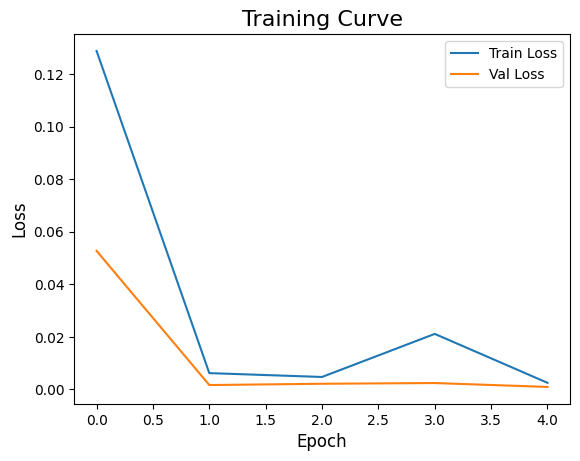

In [ ]:
best_val_loss = np.inf
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    train_loss, train_acc = trainOneEpoch(model, train_dl, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_dl, criterion)

    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f}, Acc: {val_acc:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f'{OUT_DIR}/model_weights.pth')
        torch.save(model, f'{OUT_DIR}/model.pt')
        print('Model saved')

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Training Curve', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.show()

# Evaluate

Eval: 100%|██████████| 5/5 [00:01<00:00,  2.54it/s]

Test Loss: 0.0010, Test Acc: 1.0000

Classification Report:
                                    precision    recall  f1-score   support

The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       110
                        Test cases       1.00      1.00      1.00        20

                          accuracy                           1.00       130
                         macro avg       1.00      1.00      1.00       130
                      weighted avg       1.00      1.00      1.00       130



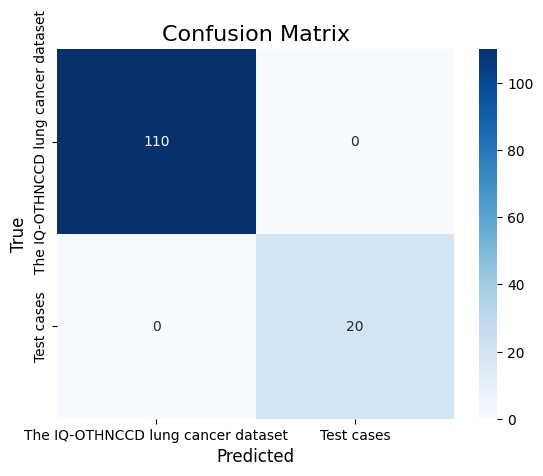

In [ ]:
model.load_state_dict(torch.load(f'{OUT_DIR}/model_weights.pth'))
test_loss, test_acc, preds, labels = evaluate(model, test_dl, criterion)
print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

print('\nClassification Report:')
print(classification_report(labels, preds, target_names=classes))

cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix', fontsize=16)
plt.show()

In [ ]:
import torch.nn.functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

        def save_gradient(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        def save_activation(module, input, output):
            self.activations = output

        self.hooks.append(self.target_layer.register_forward_hook(save_activation))
        self.hooks.append(self.target_layer.register_backward_hook(save_gradient))

    def generate_heatmap(self, input_image, class_idx):
        self.model.zero_grad()
        output = self.model(input_image)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        loss = output[0, class_idx]
        loss.backward()

        # Global Average Pooling gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)

        # (activations)
        heatmap = torch.sum(weights * self.activations, dim=1).squeeze()

        # ReLU
        heatmap = F.relu(heatmap)

        # Normalize heatmap
        heatmap /= torch.max(heatmap)
        return heatmap.detach().cpu().numpy(), class_idx

    def remove_hooks(self):
        for hook in self.hooks:
            hook.remove()

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1870: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


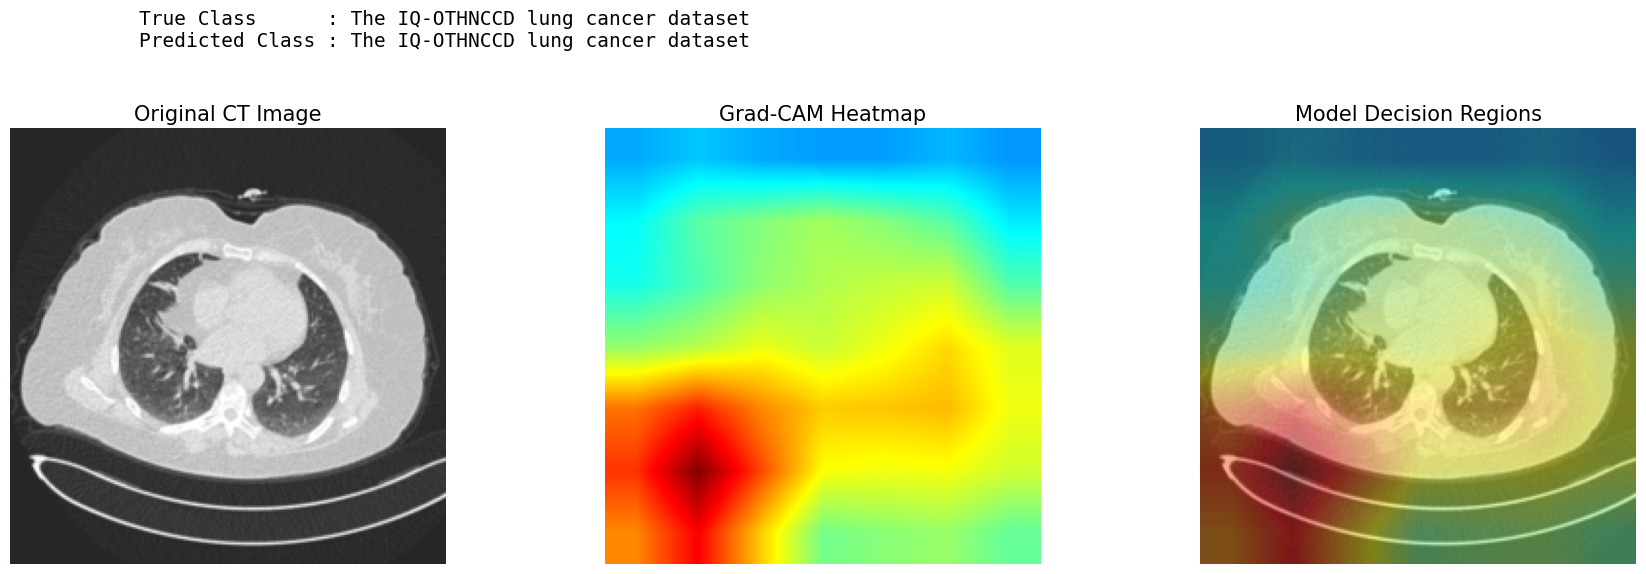

In [ ]:
import cv2

def visualize_gradcam_result(model, dataset, idx, classes):
    # 1. Grad-CAM
    target_layer = model.layer4[-1]
    grad_cam = GradCAM(model, target_layer)

    # 2.
    img_tensor, label_idx = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    # 3.  Heatmap Prediction
    heatmap, pred_idx = grad_cam.generate_heatmap(input_tensor, class_idx=None)

    # 4.  (تحويلها لـ 0-255 و NumPy)
    inv_normalize = T.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    img_show = inv_normalize(img_tensor).permute(1, 2, 0).cpu().numpy()
    img_show = np.clip(img_show, 0, 1)
    img_uint8 = (img_show * 255).astype(np.uint8)

    # 5. Heatmap
    heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    # JET colormap
    heatmap_color = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # 6. Heatmap (Decision Regions)
    #
    superimposed_img = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)

    # 7.
    plt.figure(figsize=(18, 6))

    # True و Predicted
    plt.suptitle(f"True Class      : {classes[label_idx]}\nPredicted Class : {classes[pred_idx]}",
                 fontsize=14, family='monospace', x=0.12, ha='left')

    # Original CT Image
    plt.subplot(1, 3, 1)
    plt.imshow(img_uint8)
    plt.title("Original CT Image", fontsize=15)
    plt.axis('off')

    # Grad-CAM Heatmap
    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_color)
    plt.title("Grad-CAM Heatmap", fontsize=15)
    plt.axis('off')

    # Model Decision Regions
    plt.subplot(1, 3, 3)
    plt.imshow(superimposed_img)
    plt.title("Model Decision Regions", fontsize=15)
    plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

    grad_cam.remove_hooks()

visualize_gradcam_result(model, test_ds, random.randint(0, len(test_ds)-1), classes)


--- Detailed Performance per Class ---
Class: The IQ-OTHNCCD lung cancer dataset
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Class: Test cases
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000



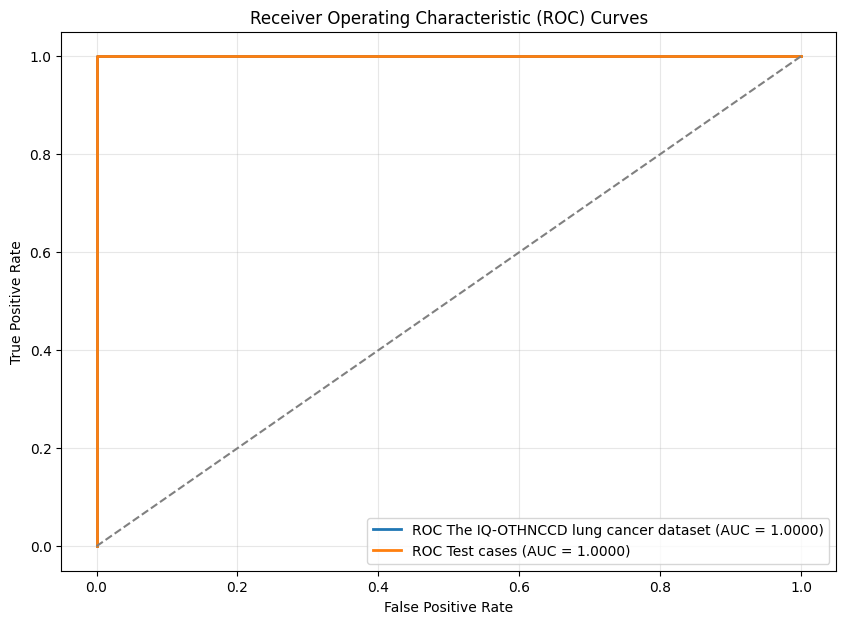

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average=None)

print("\n--- Detailed Performance per Class ---")
for i, cls_name in enumerate(classes):
    print(f"Class: {cls_name}")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall:    {recall[i]:.4f}")
    print(f"  F1-Score:  {f1[i]:.4f}\n")

# 2. Collect probabilities
model.eval()
all_probs = []
with torch.no_grad():
    for imgs, _ in test_dl:
        outputs = model(imgs.to(DEVICE))
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())
all_probs = np.array(all_probs)

# 3. Binarize labels — fix for binary (2-class) edge case
y_test_bin = label_binarize(labels, classes=range(len(classes)))
if y_test_bin.shape[1] == 1:                          # binary case
    y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

# 4. ROC Curves
plt.figure(figsize=(10, 7))
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC {classes[i]} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
model.eval()
example_input = torch.rand(1, 3, 224, 224).to(DEVICE)
traced_script_module = torch.jit.trace(model, example_input)
traced_script_module.save("model_jit.pt")

Using Colab cache for faster access to the 'iqothnccd-lung-cancer-dataset' dataset.
Device: cuda
Data root: /kaggle/input/iqothnccd-lung-cancer-dataset
Classes (2): ['Test cases', 'The IQ-OTHNCCD lung cancer dataset']
Total samples: 1294
Train: 905 | Val: 194 | Test: 195

  Training: ResNet-18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]



Epoch 1/15


Eval: 100%|██████████| 7/7 [00:01<00:00,  5.04it/s]


  Train Loss: 0.0723  Acc: 0.9890
  Val   Loss: 0.0946  Acc: 0.9639
  ✅ Model saved

Epoch 2/15


...

  Train Loss: 0.0020  Acc: 0.9989
  Val   Loss: 0.0003  Acc: 1.0000

Epoch 15/15


Eval: 100%|██████████| 7/7 [00:01<00:00,  5.04it/s]


  Train Loss: 0.0005  Acc: 1.0000
  Val   Loss: 0.0003  Acc: 1.0000


Eval: 100%|██████████| 7/7 [00:02<00:00,  3.29it/s]



Test Loss: 0.0002  Test Acc: 1.0000

Classification Report:
                                    precision    recall  f1-score   support

                        Test cases       1.00      1.00      1.00        20
The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       175

                          accuracy                           1.00       195
                         macro avg       1.00      1.00      1.00       195
                      weighted avg       1.00      1.00      1.00       195



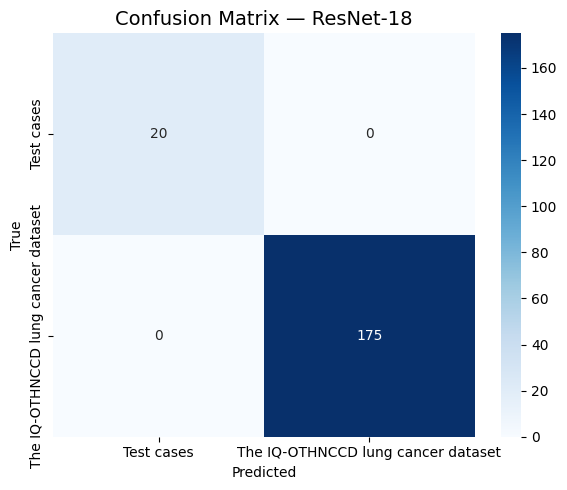

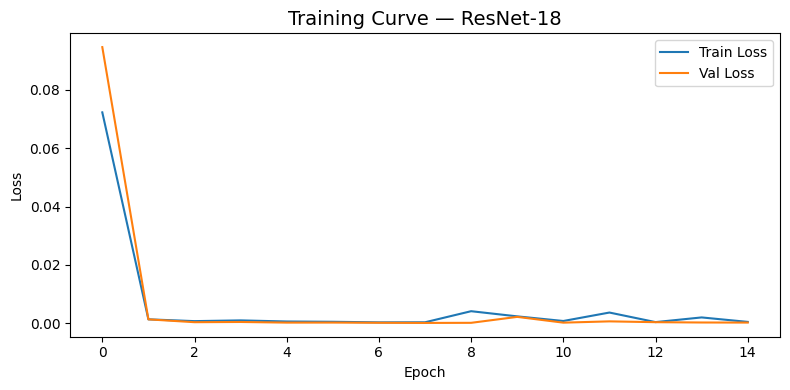


  Training: EfficientNet-B1
Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 195MB/s]



Epoch 1/15


Eval: 100%|██████████| 7/7 [00:01<00:00,  4.14it/s]


  Train Loss: 0.4390  Acc: 0.9182
  Val   Loss: 0.2052  Acc: 0.9948
  ✅ Model saved

Epoch 2/15


...

  Train Loss: 0.0005  Acc: 1.0000
  Val   Loss: 0.0002  Acc: 1.0000

Epoch 15/15


Eval: 100%|██████████| 7/7 [00:01<00:00,  4.59it/s]


  Train Loss: 0.0005  Acc: 1.0000
  Val   Loss: 0.0001  Acc: 1.0000
  ✅ Model saved


Eval: 100%|██████████| 7/7 [00:01<00:00,  4.83it/s]



Test Loss: 0.0002  Test Acc: 1.0000

Classification Report:
                                    precision    recall  f1-score   support

                        Test cases       1.00      1.00      1.00        20
The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       175

                          accuracy                           1.00       195
                         macro avg       1.00      1.00      1.00       195
                      weighted avg       1.00      1.00      1.00       195



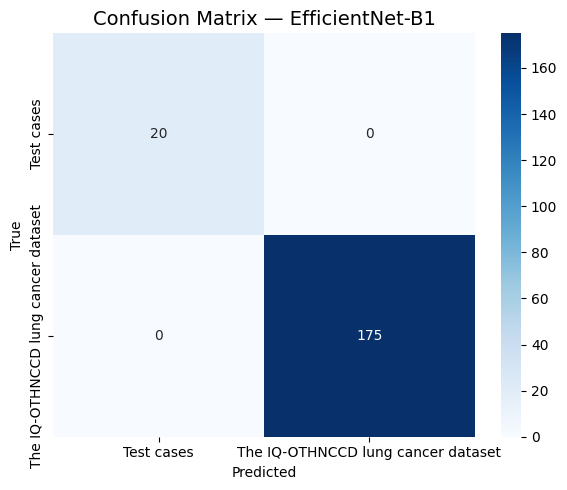

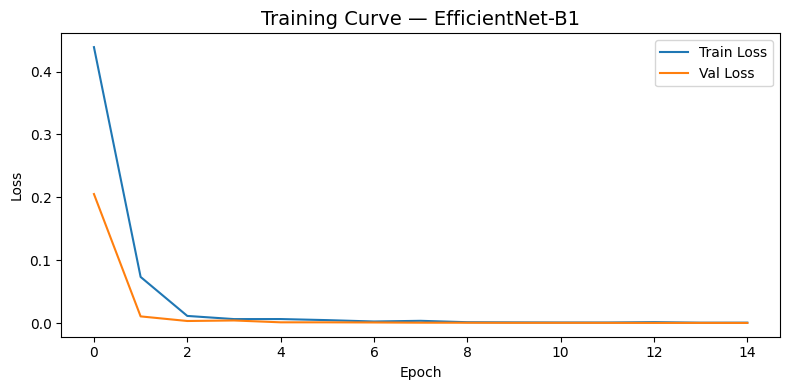


  Training: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 166MB/s]



Epoch 1/15


Eval: 100%|██████████| 7/7 [00:01<00:00,  5.01it/s]


  Train Loss: 0.3334  Acc: 0.9227
  Val   Loss: 0.1832  Acc: 0.9794
  ✅ Model saved

Epoch 2/15


...

  Train Loss: 0.0011  Acc: 1.0000
  Val   Loss: 0.0005  Acc: 1.0000
  ✅ Model saved

Epoch 15/15


Eval: 100%|██████████| 7/7 [00:01<00:00,  5.21it/s]


  Train Loss: 0.0008  Acc: 1.0000
  Val   Loss: 0.0005  Acc: 1.0000
  ✅ Model saved


Eval: 100%|██████████| 7/7 [00:01<00:00,  5.30it/s]



Test Loss: 0.0005  Test Acc: 1.0000

Classification Report:
                                    precision    recall  f1-score   support

                        Test cases       1.00      1.00      1.00        20
The IQ-OTHNCCD lung cancer dataset       1.00      1.00      1.00       175

                          accuracy                           1.00       195
                         macro avg       1.00      1.00      1.00       195
                      weighted avg       1.00      1.00      1.00       195



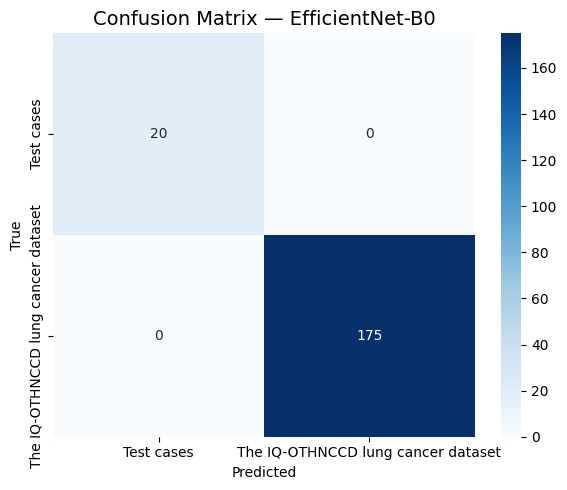

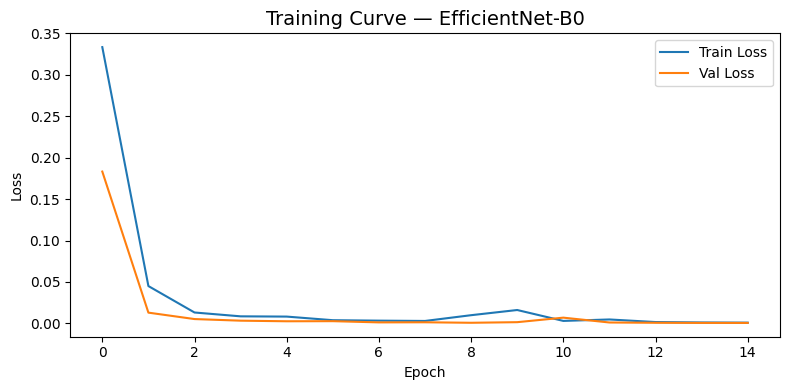


  MODEL COMPARISON DASHBOARD


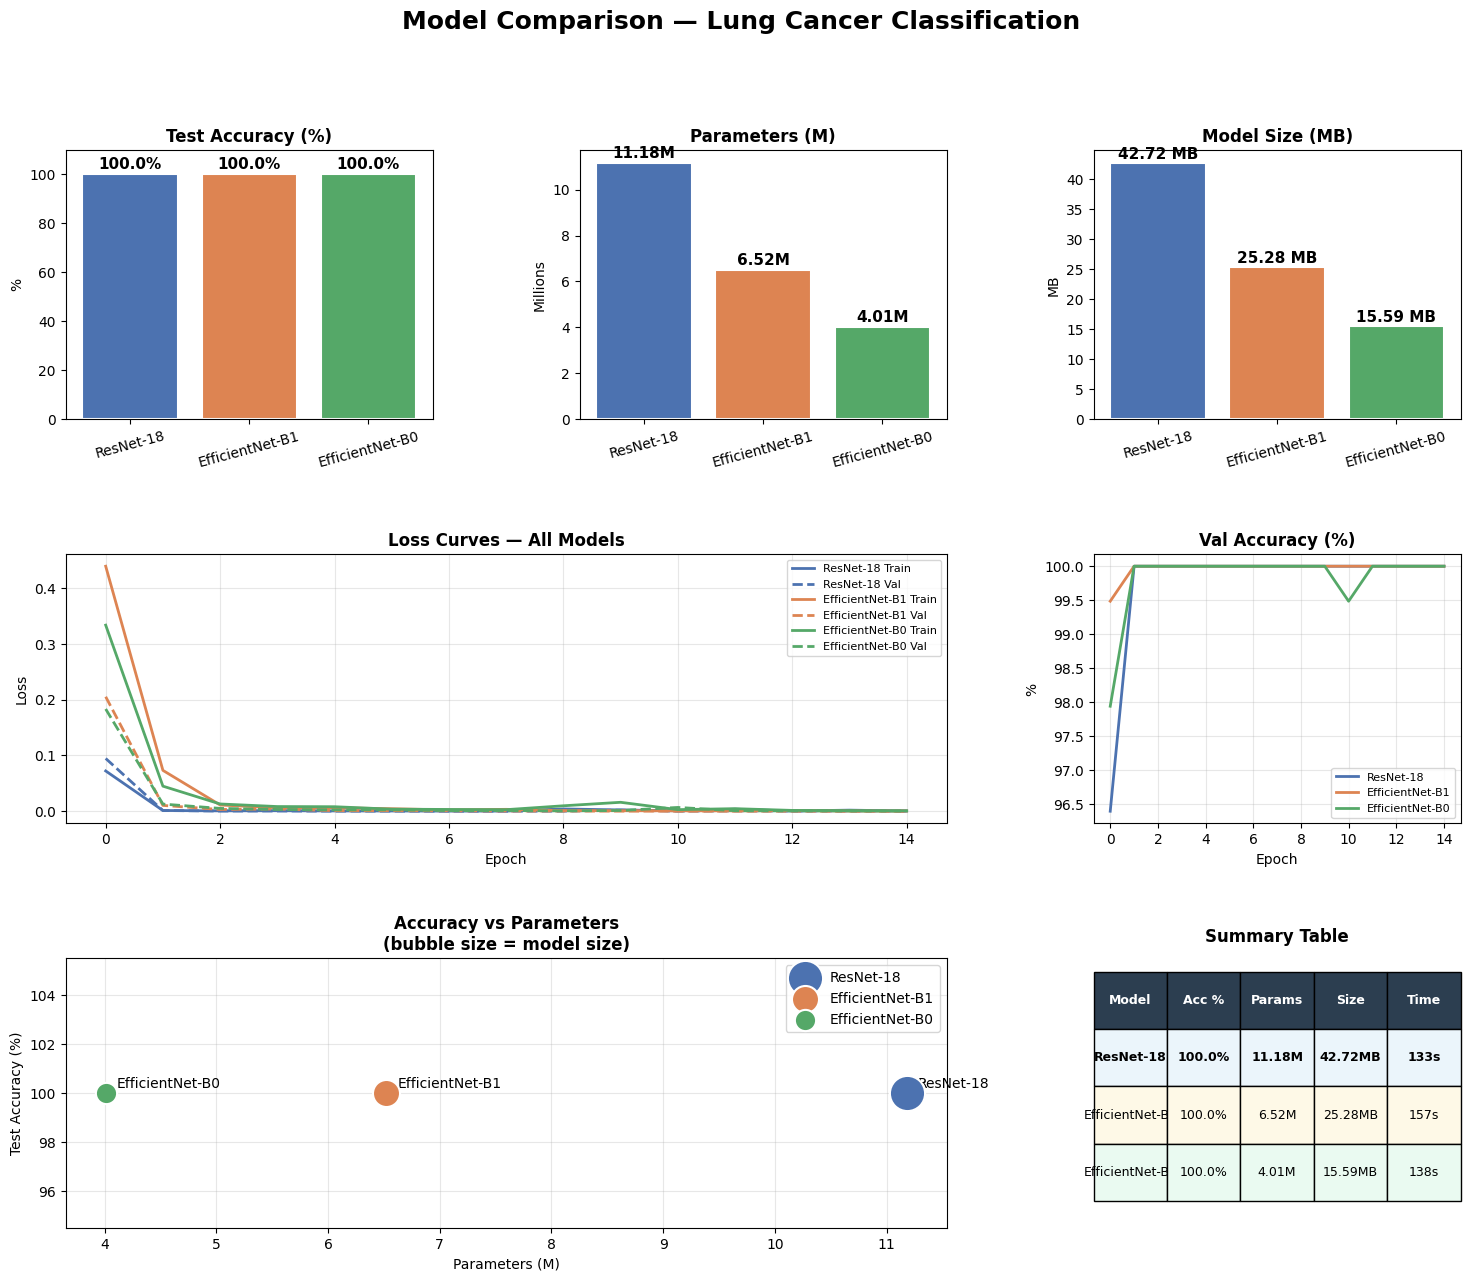


📊 Dashboard saved → /kaggle/working/outputs/comparison_dashboard.png

───────────────────────────────────────────────────────
  Model                    Acc    Params     Size     Time
───────────────────────────────────────────────────────
  ResNet-18             100.0%   11.18M   42.7MB    133s ⭐
  EfficientNet-B1       100.0%    6.52M   25.3MB    157s ⭐
  EfficientNet-B0       100.0%    4.01M   15.6MB    138s ⭐
───────────────────────────────────────────────────────
📋 Results saved → /kaggle/working/outputs/results.json


In [8]:
"""
Lung Cancer Classification - 3 Model Comparison
Models: ResNet-18 | EfficientNet-B1 | EfficientNet-B0
Framework: PyTorch + torchvision
"""

# ─── 0. IMPORTS ────────────────────────────────────────────────────────────────
import os, time, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import (
    resnet18,        ResNet18_Weights,
    efficientnet_b1, EfficientNet_B1_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)
from sklearn.metrics import classification_report, confusion_matrix

# ─── 1. CONFIG ─────────────────────────────────────────────────────────────────
import kagglehub
path = kagglehub.dataset_download("adityamahimkar/iqothnccd-lung-cancer-dataset")
DATA_DIR    = path                        # tự động lấy path từ kagglehub
OUT_DIR     = "/kaggle/working/outputs"
os.makedirs(OUT_DIR, exist_ok=True)

IMG_SIZE    = 224
BATCH_SIZE  = 32
EPOCHS      = 15
LR          = 1e-4
WEIGHT_DECAY= 1e-4
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ─── 2. DATASET ────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Tìm thư mục chứa ảnh (tự động detect subfolder nếu cần)
root = Path(DATA_DIR)
candidates = [root] + [d for d in root.iterdir() if d.is_dir()]
DATA_ROOT = next(
    (d for d in candidates if any(True for _ in d.glob("*/*.jpg")) or
                               any(True for _ in d.glob("*/*.png"))),
    root
)
print(f"Data root: {DATA_ROOT}")

full_ds = datasets.ImageFolder(str(DATA_ROOT))
classes = full_ds.classes
NUM_CLASSES = len(classes)
print(f"Classes ({NUM_CLASSES}): {classes}")
print(f"Total samples: {len(full_ds)}")

# Train / Val / Test split 70/15/15
n = len(full_ds)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
train_ds, val_ds, test_ds = torch.utils.data.random_split(
    full_ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

# Gán transform riêng
train_ds.dataset.transform = train_tf
val_ds.dataset.transform   = val_tf
test_ds.dataset.transform  = val_tf

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

# ─── 3. MODEL FACTORY ──────────────────────────────────────────────────────────
def build_model(name: str) -> nn.Module:
    if name == "resnet18":
        m = resnet18(weights=ResNet18_Weights.DEFAULT)
        m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)

    elif name == "efficientnet_b1":
        m = efficientnet_b1(weights=EfficientNet_B1_Weights.DEFAULT)
        in_f = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_f, NUM_CLASSES)

    elif name == "efficientnet_b0":
        m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_f = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_f, NUM_CLASSES)

    return m.to(DEVICE)


def count_params(m: nn.Module) -> int:
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


def model_size_mb(path: str) -> float:
    return os.path.getsize(path) / (1024 ** 2)

# ─── 4. TRAIN / EVAL FUNCTIONS ────────────────────────────────────────────────
def trainOneEpoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, correct = 0, 0
    for imgs, labels in tqdm(loader, desc="Train", leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
    return running_loss / len(loader.dataset), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct = 0, 0
    preds_all, labels_all = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Eval", leave=True):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(1)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())
            correct += (preds == labels).sum().item()
    return (running_loss / len(loader.dataset),
            correct / len(loader.dataset),
            np.array(preds_all),
            np.array(labels_all))

# ─── 5. TRAINING LOOP ─────────────────────────────────────────────────────────
MODEL_CONFIGS = [
    ("resnet18",        "ResNet-18"),
    ("efficientnet_b1", "EfficientNet-B1"),
    ("efficientnet_b0", "EfficientNet-B0"),
]

all_results = {}   # lưu kết quả để so sánh cuối

for model_key, model_name in MODEL_CONFIGS:
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    model = build_model(model_key)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=3)

    weight_path = f"{OUT_DIR}/{model_key}_weights.pth"
    best_val_loss = np.inf
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    t0 = time.time()

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        train_loss, train_acc = trainOneEpoch(model, train_dl, criterion, optimizer)
        val_loss,   val_acc, _, _ = evaluate(model, val_dl, criterion)
        scheduler.step(val_loss)

        train_losses.append(train_loss);  val_losses.append(val_loss)
        train_accs.append(train_acc);     val_accs.append(val_acc)

        print(f"  Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), weight_path)
            print("  ✅ Model saved")

    train_time = time.time() - t0

    # ── Evaluate on test set ──
    model.load_state_dict(torch.load(weight_path))
    test_loss, test_acc, preds, labels = evaluate(model, test_dl, criterion)
    print(f"\nTest Loss: {test_loss:.4f}  Test Acc: {test_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=classes))

    # ── Confusion Matrix ──
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title(f"Confusion Matrix — {model_name}", fontsize=14)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{model_key}_confusion.png", dpi=120)
    plt.show()

    # ── Training Curve ──
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses,   label="Val Loss")
    plt.title(f"Training Curve — {model_name}", fontsize=14)
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/{model_key}_curve.png", dpi=120)
    plt.show()

    # ── Lưu kết quả ──
    all_results[model_key] = {
        "name":        model_name,
        "test_acc":    round(test_acc * 100, 2),
        "test_loss":   round(test_loss, 4),
        "best_val_acc":round(max(val_accs) * 100, 2),
        "params_M":    round(count_params(model) / 1e6, 2),
        "size_MB":     round(model_size_mb(weight_path), 2),
        "train_time_s":round(train_time, 1),
        "train_losses":train_losses,
        "val_losses":  val_losses,
        "train_accs":  train_accs,
        "val_accs":    val_accs,
    }

# ─── 6. COMPARISON DASHBOARD ──────────────────────────────────────────────────
print("\n" + "="*60)
print("  MODEL COMPARISON DASHBOARD")
print("="*60)

names     = [v["name"]        for v in all_results.values()]
test_accs = [v["test_acc"]    for v in all_results.values()]
params    = [v["params_M"]    for v in all_results.values()]
sizes     = [v["size_MB"]     for v in all_results.values()]
times     = [v["train_time_s"]for v in all_results.values()]
colors    = ["#4C72B0", "#DD8452", "#55A868"]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Model Comparison — Lung Cancer Classification",
             fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# ── 6a. Test Accuracy bar ──
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(names, test_accs, color=colors, edgecolor="white", linewidth=1.5)
ax1.set_title("Test Accuracy (%)", fontweight="bold")
ax1.set_ylim(0, 110)
ax1.set_ylabel("%")
for bar, val in zip(bars, test_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax1.tick_params(axis="x", rotation=15)

# ── 6b. Parameters bar ──
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(names, params, color=colors, edgecolor="white", linewidth=1.5)
ax2.set_title("Parameters (M)", fontweight="bold")
ax2.set_ylabel("Millions")
for bar, val in zip(bars2, params):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{val}M", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax2.tick_params(axis="x", rotation=15)

# ── 6c. Model size bar ──
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(names, sizes, color=colors, edgecolor="white", linewidth=1.5)
ax3.set_title("Model Size (MB)", fontweight="bold")
ax3.set_ylabel("MB")
for bar, val in zip(bars3, sizes):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{val} MB", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax3.tick_params(axis="x", rotation=15)

# ── 6d. Train Loss curves (overlay) ──
ax4 = fig.add_subplot(gs[1, :2])
for (key, res), color in zip(all_results.items(), colors):
    ax4.plot(res["train_losses"], label=f"{res['name']} Train", color=color, linewidth=2)
    ax4.plot(res["val_losses"],   label=f"{res['name']} Val",   color=color, linewidth=2, linestyle="--")
ax4.set_title("Loss Curves — All Models", fontweight="bold")
ax4.set_xlabel("Epoch"); ax4.set_ylabel("Loss")
ax4.legend(fontsize=8); ax4.grid(alpha=0.3)

# ── 6e. Val Accuracy curves (overlay) ──
ax5 = fig.add_subplot(gs[1, 2])
for (key, res), color in zip(all_results.items(), colors):
    ax5.plot([a*100 for a in res["val_accs"]], label=res["name"], color=color, linewidth=2)
ax5.set_title("Val Accuracy (%)", fontweight="bold")
ax5.set_xlabel("Epoch"); ax5.set_ylabel("%")
ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

# ── 6f. Scatter: Accuracy vs Parameters (efficiency plot) ──
ax6 = fig.add_subplot(gs[2, :2])
for (key, res), color in zip(all_results.items(), colors):
    ax6.scatter(res["params_M"], res["test_acc"],
                color=color, s=res["size_MB"]*15,
                label=res["name"], zorder=5, edgecolors="white", linewidth=1.5)
    ax6.annotate(res["name"],
                 (res["params_M"], res["test_acc"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)
ax6.set_title("Accuracy vs Parameters\n(bubble size = model size)", fontweight="bold")
ax6.set_xlabel("Parameters (M)"); ax6.set_ylabel("Test Accuracy (%)")
ax6.grid(alpha=0.3); ax6.legend()

# ── 6g. Summary table ──
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis("off")
table_data = [["Model", "Acc %", "Params", "Size", "Time"]]
for v in all_results.values():
    table_data.append([
        v["name"],
        f"{v['test_acc']}%",
        f"{v['params_M']}M",
        f"{v['size_MB']}MB",
        f"{v['train_time_s']:.0f}s",
    ])
tbl = ax7.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc="center", loc="center",
                bbox=[0, 0.1, 1, 0.85])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
# Header styling
for j in range(5):
    tbl[0, j].set_facecolor("#2C3E50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")
# Row colors
row_colors = ["#EBF5FB", "#FEF9E7", "#EAFAF1"]
for i, color in enumerate(row_colors, 1):
    for j in range(5):
        tbl[i, j].set_facecolor(color)
# Highlight best accuracy
best_idx = test_accs.index(max(test_accs)) + 1
for j in range(5):
    tbl[best_idx, j].set_text_props(fontweight="bold")
ax7.set_title("Summary Table", fontweight="bold", pad=12)

plt.savefig(f"{OUT_DIR}/comparison_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n📊 Dashboard saved → {OUT_DIR}/comparison_dashboard.png")

# ── 6h. Print text summary ──
print(f"\n{'─'*55}")
print(f"  {'Model':<20} {'Acc':>7} {'Params':>9} {'Size':>8} {'Time':>8}")
print(f"{'─'*55}")
for v in all_results.values():
    marker = " ⭐" if v["test_acc"] == max(test_accs) else ""
    print(f"  {v['name']:<20} {v['test_acc']:>6.1f}% "
          f"{v['params_M']:>7.2f}M "
          f"{v['size_MB']:>6.1f}MB "
          f"{v['train_time_s']:>6.0f}s{marker}")
print(f"{'─'*55}")

# Lưu kết quả JSON (bỏ list losses để gọn)
summary = {k: {kk: vv for kk, vv in v.items()
               if kk not in ("train_losses","val_losses","train_accs","val_accs")}
           for k, v in all_results.items()}
with open(f"{OUT_DIR}/results.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"📋 Results saved → {OUT_DIR}/results.json")